# Download Audio MNIST Dataset

Downloads the [Audio MNIST](https://huggingface.co/datasets/gilkeyio/AudioMNIST) dataset from Hugging Face and saves metadata to `data/processed/`.

In [2]:
from pathlib import Path
from datasets import load_dataset, Audio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path("..").resolve()
DATA_DIR = PROJECT_DIR / "data" / "processed"
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
ds = load_dataset("gilkeyio/AudioMNIST")
ds = ds.cast_column("audio", Audio(decode=False))

print(f"Train: {len(ds['train'])} samples")
print(f"Test:  {len(ds['test'])} samples")
print(f"Columns: {ds['train'].column_names}")

Train: 24000 samples
Test:  6000 samples
Columns: ['speaker_id', 'audio', 'digit', 'gender', 'accent', 'age', 'native_speaker', 'origin']


In [4]:
records = [{
    "digit": s["digit"],
    "speaker_id": s["speaker_id"],
    "gender": "male" if s["gender"] == 0 else "female",
    "accent": s["accent"],
    "age": s["age"],
    "origin": s["origin"],
    "split": split_name,
} for split_name, split in ds.items() for s in split]

df = pd.DataFrame(records)
df.to_csv(DATA_DIR / "audio_mnist_metadata.csv", index=False)
print(f"Saved: {DATA_DIR / 'audio_mnist_metadata.csv'}")
print(f"Total: {len(df)} records")
df.head()

Saved: C:\Users\Teva\Desktop\Repertoire trié\Cours\Erasmus\Practice1\SDOML-project1\data\processed\audio_mnist_metadata.csv
Total: 30000 records


,digit,speaker_id,gender,accent,age,origin,split
0,7,59,female,German,31.0,"Europe, Germany, Berlin",train
1,7,59,female,German,31.0,"Europe, Germany, Berlin",train
2,2,59,female,German,31.0,"Europe, Germany, Berlin",train
3,3,59,female,German,31.0,"Europe, Germany, Berlin",train
4,9,59,female,German,31.0,"Europe, Germany, Berlin",train


### AUDIO MNIST ANALYSIS
Before creating the model, we first made a brief analysis of the dataset itself to check for possible biases. According to the dataset [source](https://huggingface.co/datasets/gilkeyio/AudioMNIST):

*"The audioMNIST dataset has 50 English recordings per digit (0-9) of 60 speakers. There are 60 participants in total, with 12 being women and 48 being men, all featuring a diverse range of accents and country of origin. Their ages vary from 22 to 61 years old. This is a great dataset to explore a simple audio classification problem: either the digit or the gender."*

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   digit       30000 non-null  int64  
 1   speaker_id  30000 non-null  str    
 2   gender      30000 non-null  str    
 3   accent      30000 non-null  str    
 4   age         29500 non-null  float64
 5   origin      30000 non-null  str    
 6   split       30000 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 2.8 MB
None


In [6]:
digit_counts = df["digit"].value_counts().sort_index().reset_index()
digit_counts.columns = ["Digit", "Count"]
print(digit_counts)

   Digit  Count
0      0   3000
1      1   3000
2      2   3000
3      3   3000
4      4   3000
5      5   3000
6      6   3000
7      7   3000
8      8   3000
9      9   3000


Each number has the same amount of samples, so the dataset is well-distributed in this aspect.

After that, we checked the details from the speakers

In [7]:
df["age"].value_counts()

age
26.0    5000
27.0    3000
23.0    3000
25.0    3000
31.0    2500
24.0    2000
30.0    2000
28.0    2000
29.0    1500
22.0    1500
33.0    1000
61.0     500
32.0     500
35.0     500
41.0     500
34.0     500
36.0     500
Name: count, dtype: int64

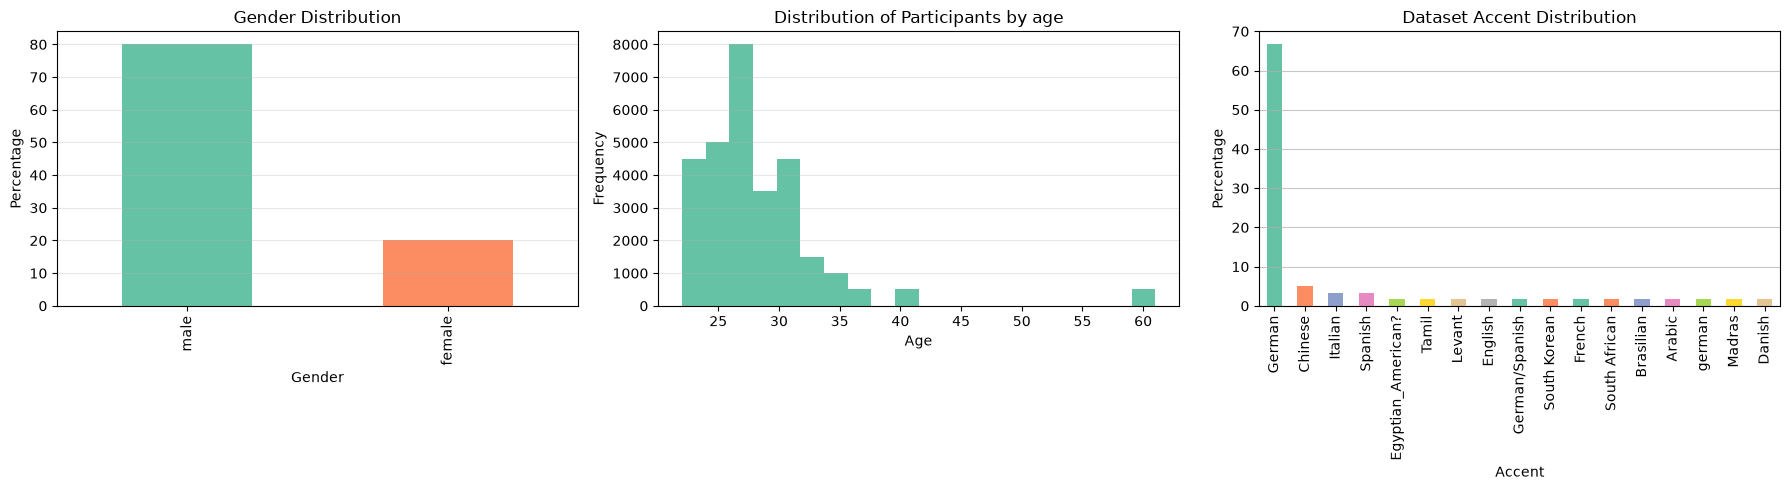


Gender: 80.0% Male, 20.0% Female
Accent: {'German': np.float64(66.67), 'Chinese': np.float64(5.0), 'Italian': np.float64(3.33), 'Spanish': np.float64(3.33), 'Egyptian_American?': np.float64(1.67), 'Tamil': np.float64(1.67), 'Levant': np.float64(1.67), 'English': np.float64(1.67), 'German/Spanish': np.float64(1.67), 'South Korean': np.float64(1.67), 'French': np.float64(1.67), 'South African': np.float64(1.67), 'Brasilian': np.float64(1.67), 'Arabic': np.float64(1.67), 'german': np.float64(1.67), 'Madras': np.float64(1.67), 'Danish': np.float64(1.67)}
Age range: 22.0-61.0 years


In [8]:
palette = sns.color_palette("Set2", n_colors=10)
# train_df = df[df["split"] == "train"]
# valid_df = df[df["split"] == "test"]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

#Gender distribution
gender_count = df["gender"].value_counts(normalize=True)*100 
gender_count.plot.bar(ax=axs[0], color=palette[:len(gender_count)])
axs[0].set_title("Gender Distribution")
axs[0].set_xlabel("Gender")
axs[0].set_ylabel("Percentage")
axs[0].grid(axis="y", alpha=0.3)


# Age Histogram
age_count = df["age"].value_counts(normalize=True)*100
df['age'].hist(ax=axs[1], bins=20, color=palette[0])
axs[1].set_xlabel('Age')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Distribution of Participants by age')
axs[1].grid(axis="y", alpha=0.3)
axs[1].xaxis.grid(False)


#Digit distribution
# digit_counts = df["digit"].value_counts().sort_index()
# digit_counts.plot.pie(ax=axs[1], colors=palette[:len(digit_counts)])
# axs[1].set_title("Dataset Digit Distribution")
# axs[1].set_xlabel("Digit")


#Accent distribution
accent_count = df["accent"].value_counts(normalize=True)*100
accent_count.plot.bar(ax=axs[2], color=palette[:len(accent_count)])
axs[2].set_title("Dataset Accent Distribution")
axs[2].set_xlabel("Accent")
axs[2].set_ylabel("Percentage")
axs[2].grid(axis="y", alpha=0.7)


plt.tight_layout()
plt.show()

print(f"\nGender: {gender_count["male"]}% Male, {gender_count["female"]}% Female")
print(f"Accent: {dict(accent_count.round(2))}")
print(f"Age range: {df['age'].min()}-{df['age'].max()} years")

There is a clear bias towards younger males with german accent. There is an underrepresentation of females, with only 20% of the dataset being female voices, and the representation of older voices is non-existant, with a couple of exceptions.

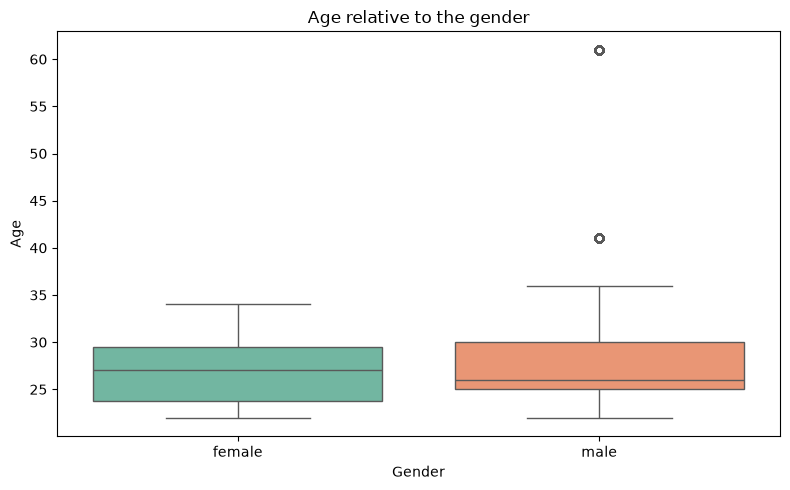

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x="gender", y="age", hue="gender", palette="Set2", legend=False, ax=ax)

ax.set_title("Age relative to the gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()

The gender groups show a very similar distribution, mainly clustered around the mid to late twenties, with only 2 exceptions for the male group.

For our dataset we transform the audio signals into 26 digit vectors to process the dataset and then we base our model on the pythorch example of the course, then adapt it to meet our needs (unit 2.2 slide 9)

In [10]:
import librosa
from tqdm import tqdm
import soundfile as sf
import io
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [11]:
N_MFCC = 13

def extract_features(audio_array, sample_rate):
    """To transform audio signal in vector"""
    mfcc = librosa.feature.mfcc(y=audio_array.astype(np.float32), sr=sample_rate, n_mfcc=N_MFCC)
    mean = mfcc.mean(axis=1)
    std = mfcc.std(axis=1)
    return np.concatenate([mean, std])

In [17]:
def decode_audio(example):
    """Décode un exemple audio HuggingFace (bytes ou path) sans passer par torchcodec."""
    audio_field = example["audio"]
    if audio_field["bytes"] is not None:
        data, sample_rate = sf.read(io.BytesIO(audio_field["bytes"]))
    else:
        data, sample_rate = sf.read(audio_field["path"])
    return data, sample_rate

ds = ds.cast_column("audio", Audio(decode=False))

def build_feature_dataset(hf_split):
    X, y = [], []
    for s in tqdm(hf_split, desc="Extract features"):
        audio_array, sr = decode_audio(s)
        features = extract_features(audio_array, sr)
        X.append(features)
        y.append(s["digit"])
    return np.array(X), np.array(y)

X_train, y_train = build_feature_dataset(ds["train"])
X_test, y_test = build_feature_dataset(ds["test"])

print(X_train.shape, y_train.shape)  # ex: (24000, 26) (24000,)

Extract features: 100%|██████████| 6000/6000 [00:14<00:00, 411.15it/s]

(24000, 26) (24000,)


In [18]:
class AudioMNISTFeaturesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AudioMNISTFeaturesDataset(X_train, y_train)
test_dataset = AudioMNISTFeaturesDataset(X_test, y_test)

# Data loaders
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

### MODEL DEFINITION

For training we will use a Multilayer Perceptron with an input of 26 neurons, two hidden layers of 64 and 32 neurons and a final output layer of 10 neurons according to the number of classes in the dataset (0-9 digits). 

More details:
- Optimizer: Adam (lr = 1e-4)
- loss function: Cross Entropy Loss

In [26]:
# Model
class Net(nn.Module):
  def __init__(self, input_dim=26, num_classes=10):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 64)
    # self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(64, num_classes)
  def forward(self, x):
    x = torch.relu(self.fc1(x))
    # x = torch.relu(self.fc2(x))
    return self.fc3(x)

In [27]:
total_loss_train = []
total_accuracy_train = []
total_loss_valid = []
total_accuracy_valid = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net(input_dim=X_train.shape[1]).to(device)
opt = optim.Adam(net.parameters(), lr=1e-4) 
loss_fn = nn.CrossEntropyLoss()

epochs = 40

all_confusion_matrices = [] # Confusion matrice part

for epoch in range(epochs):
    net.train()
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    all_preds = [] # Confusion matrice part (prediction)
    all_labels = [] # Confusion matrice part (real answer)
    
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = net(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()
        epoch_loss_train += loss.item() * xb.size(0)
        
        preds = out.argmax(1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        
    cm = confusion_matrix(all_labels, all_preds)
    all_confusion_matrices.append(cm)

    train_loss = epoch_loss_train / total_train
    train_accuracy = correct_train / total_train
    total_loss_train.append(train_loss)
    total_accuracy_train.append(train_accuracy)


    net.eval()
    epoch_loss_valid = 0.0
    correct_valid = 0
    total_valid = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = net(xb)
            loss = loss_fn(out, yb)
            
            epoch_loss_valid += loss.item() * xb.size(0)
            preds = out.argmax(1)
            correct_valid += (preds == yb).sum().item()
            total_valid += yb.size(0)

    valid_loss = epoch_loss_valid / total_valid
    valid_accuracy = correct_valid / total_valid
    total_loss_valid.append(valid_loss)
    total_accuracy_valid.append(valid_accuracy)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {valid_loss:.4f} | Val Acc: {valid_accuracy:.4f}")

Epoch 1/40 | Train Loss: 10.2144 | Train Acc: 0.2111 | Val Loss: 2.3398 | Val Acc: 0.3605
Epoch 2/40 | Train Loss: 1.6870 | Train Acc: 0.4576 | Val Loss: 1.2391 | Val Acc: 0.5487
Epoch 3/40 | Train Loss: 0.9568 | Train Acc: 0.6580 | Val Loss: 0.8204 | Val Acc: 0.7372
Epoch 4/40 | Train Loss: 0.6780 | Train Acc: 0.7747 | Val Loss: 0.6330 | Val Acc: 0.8015
Epoch 5/40 | Train Loss: 0.5307 | Train Acc: 0.8303 | Val Loss: 0.5342 | Val Acc: 0.8400
Epoch 6/40 | Train Loss: 0.4417 | Train Acc: 0.8627 | Val Loss: 0.4684 | Val Acc: 0.8610
Epoch 7/40 | Train Loss: 0.3816 | Train Acc: 0.8854 | Val Loss: 0.4290 | Val Acc: 0.8693
Epoch 8/40 | Train Loss: 0.3369 | Train Acc: 0.8992 | Val Loss: 0.4018 | Val Acc: 0.8777
Epoch 9/40 | Train Loss: 0.3052 | Train Acc: 0.9077 | Val Loss: 0.3829 | Val Acc: 0.8860
Epoch 10/40 | Train Loss: 0.2773 | Train Acc: 0.9165 | Val Loss: 0.3686 | Val Acc: 0.8870
Epoch 11/40 | Train Loss: 0.2564 | Train Acc: 0.9231 | Val Loss: 0.3528 | Val Acc: 0.8892
Epoch 12/40 | Trai

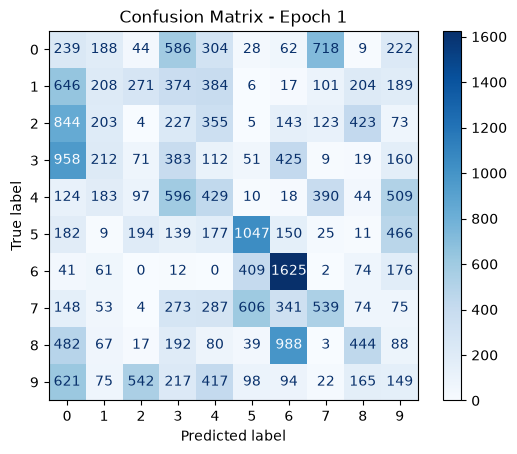

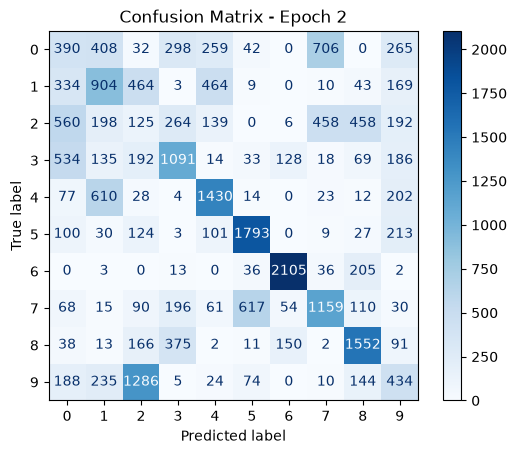

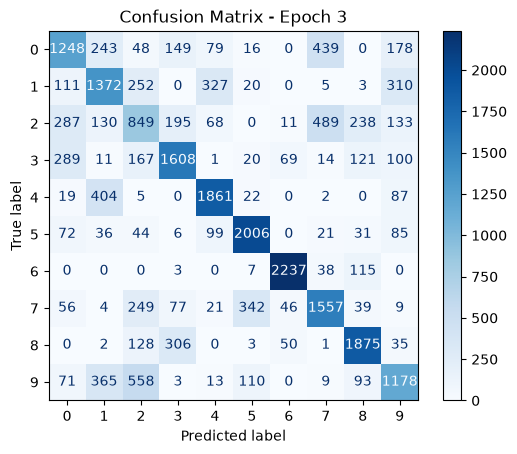

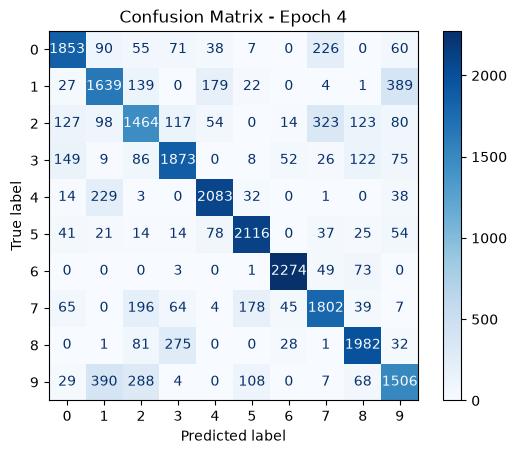

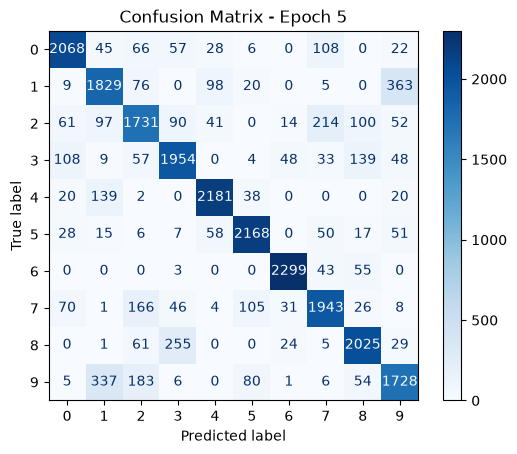

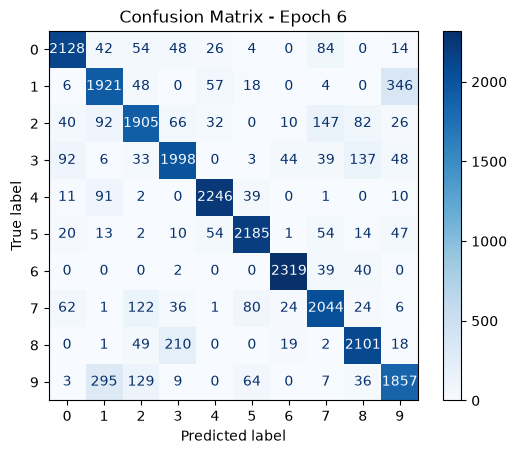

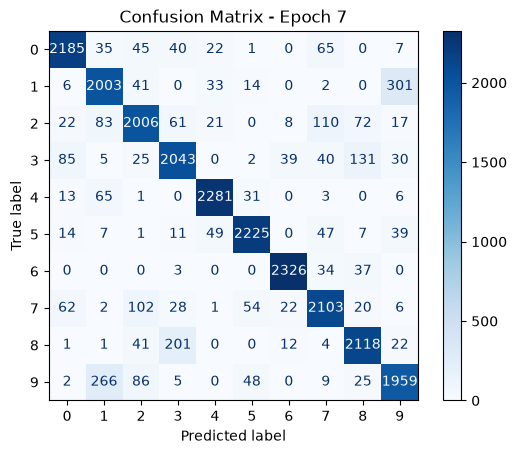

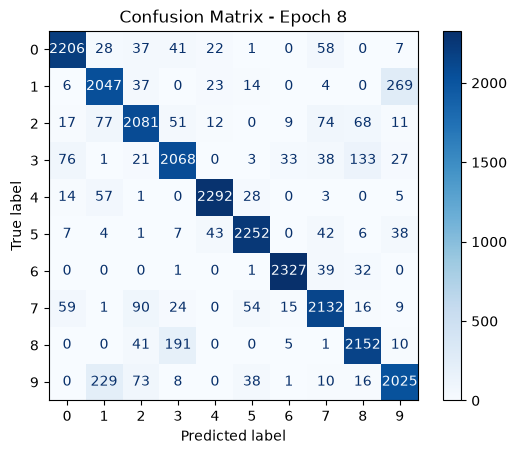

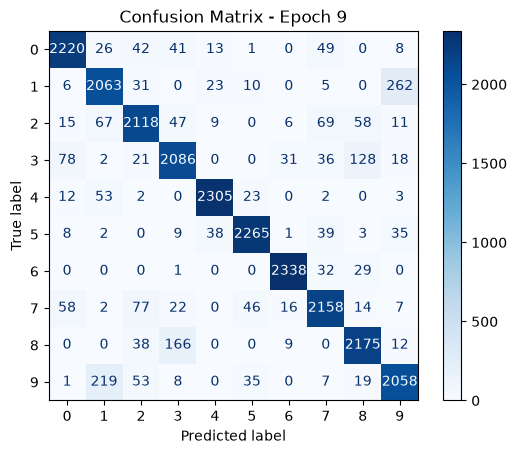

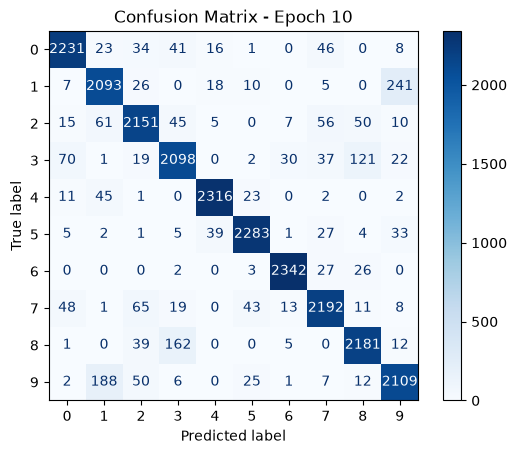

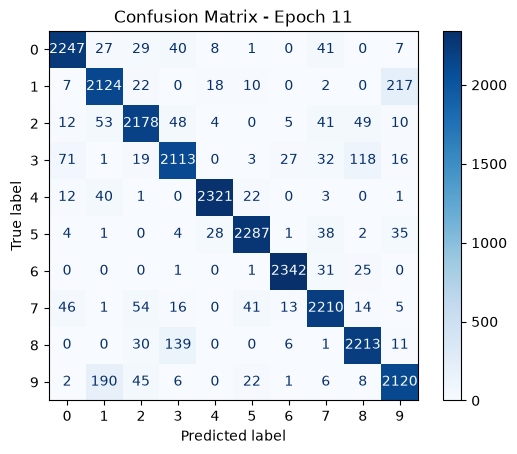

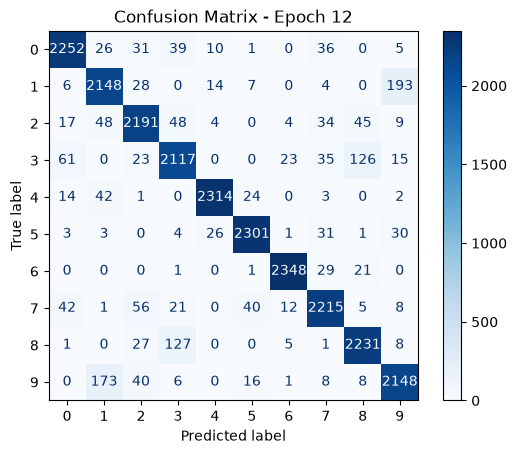

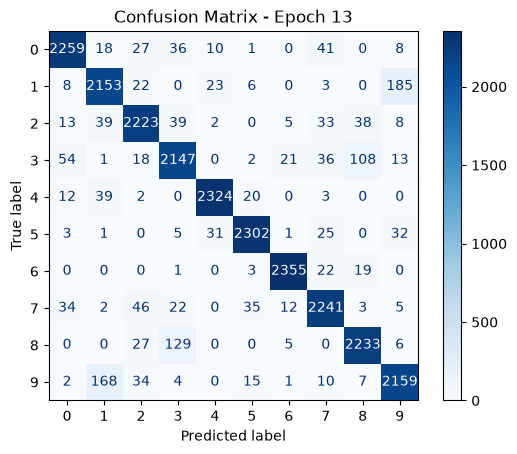

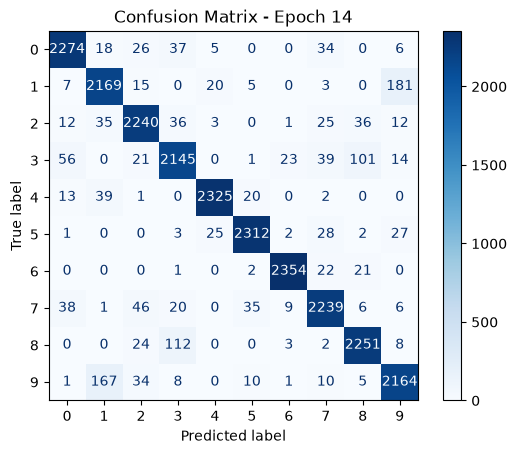

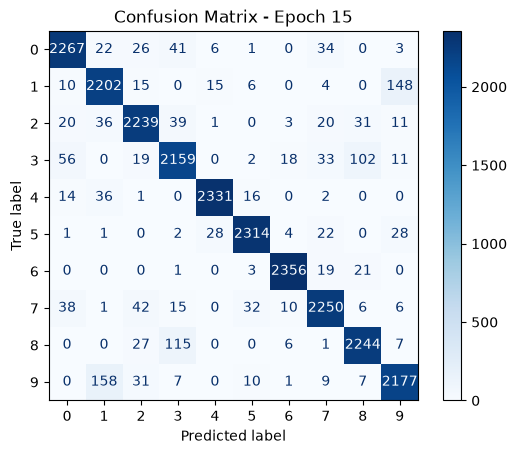

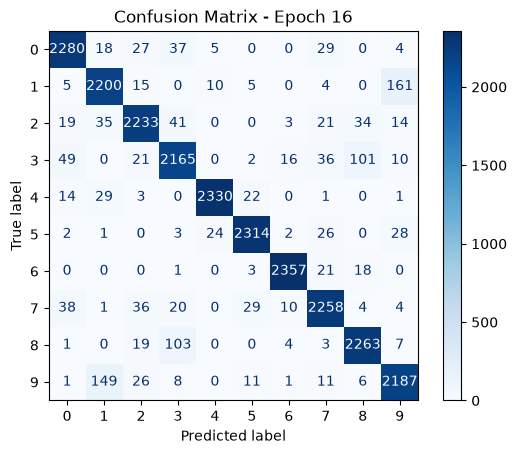

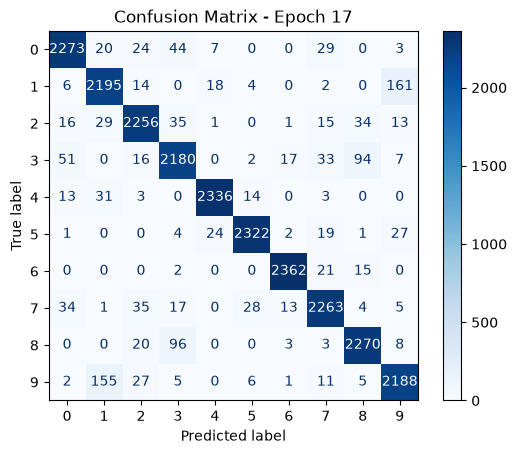

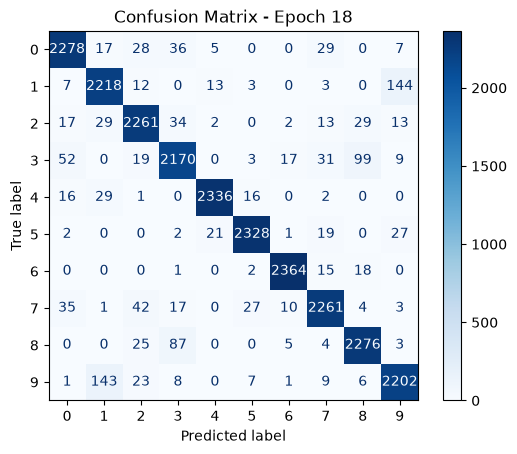

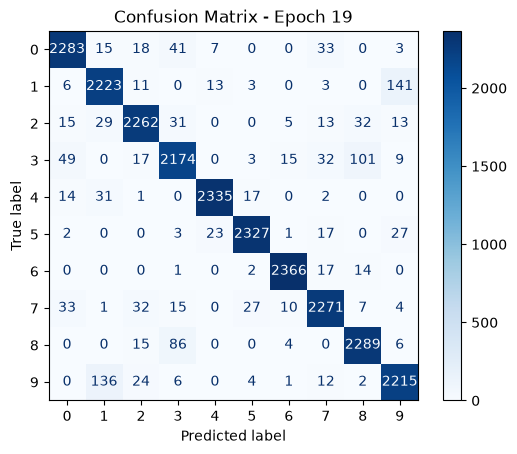

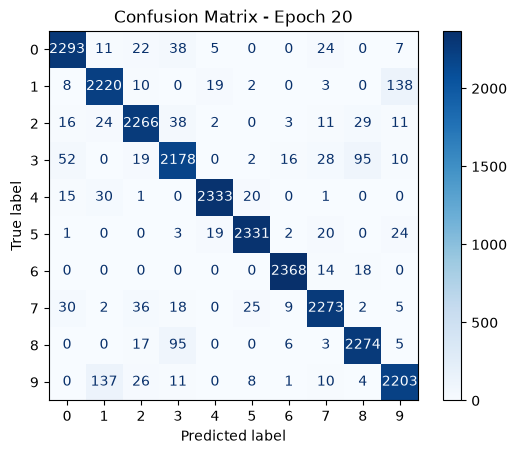

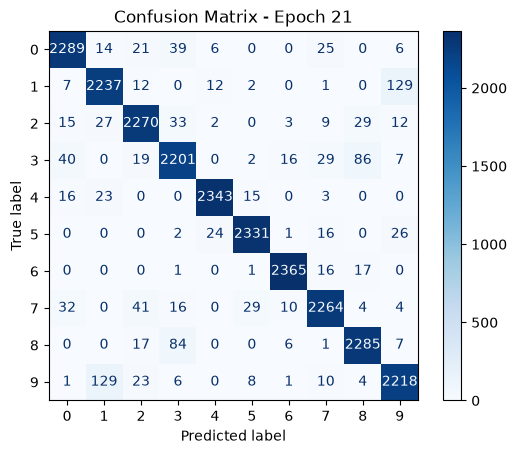

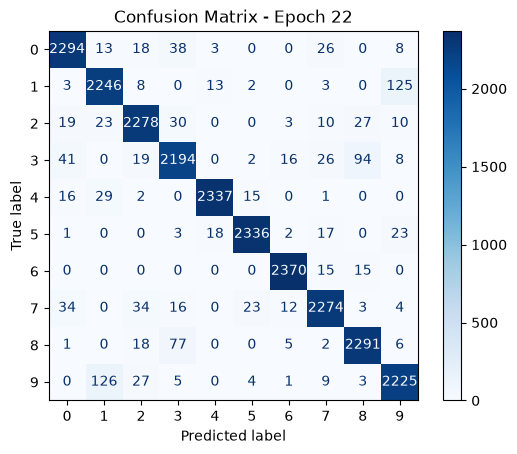

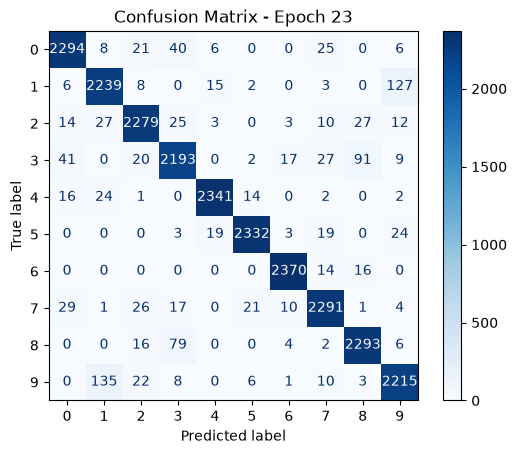

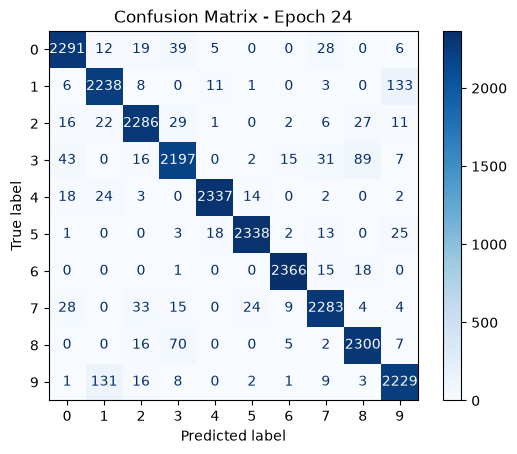

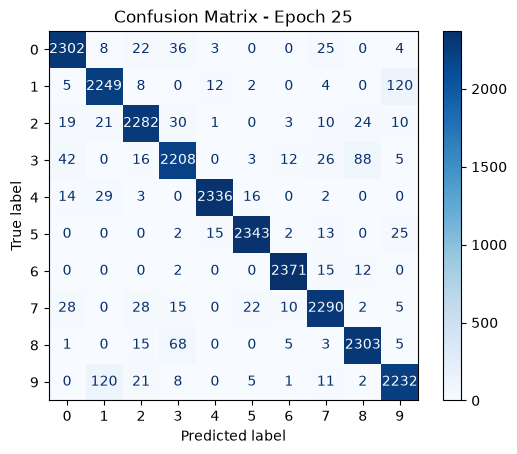

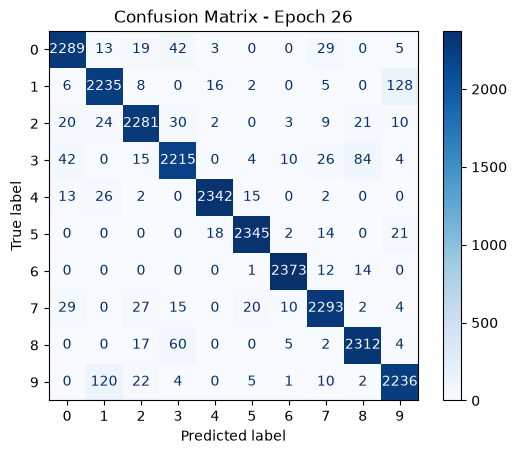

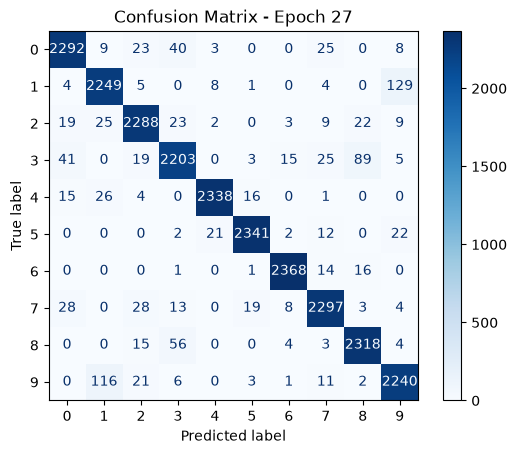

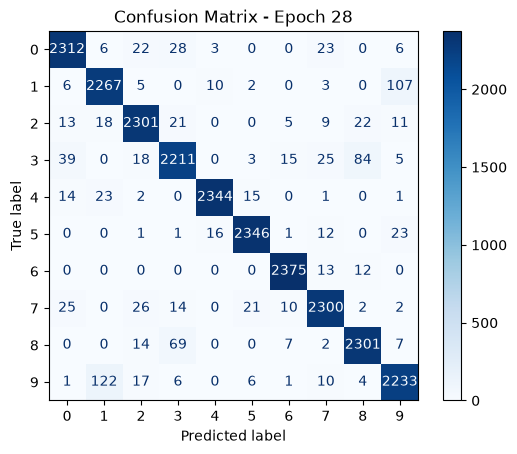

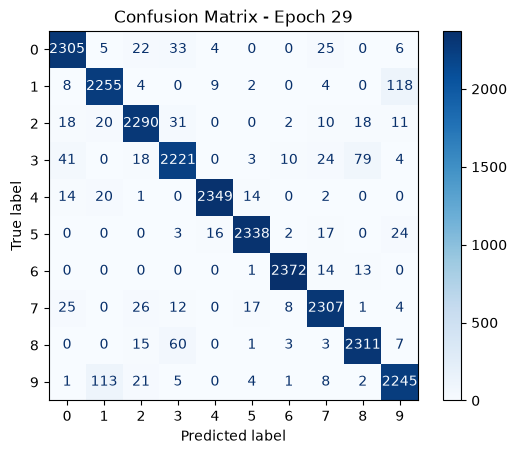

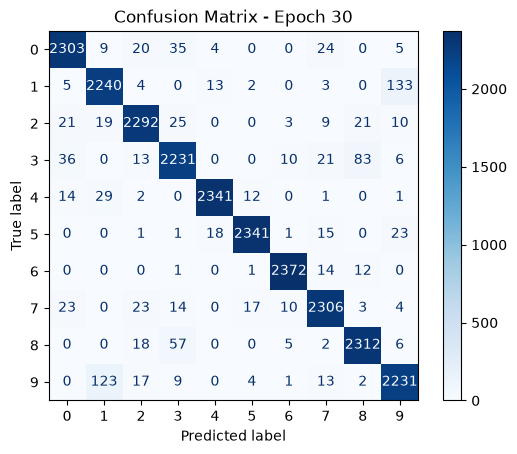

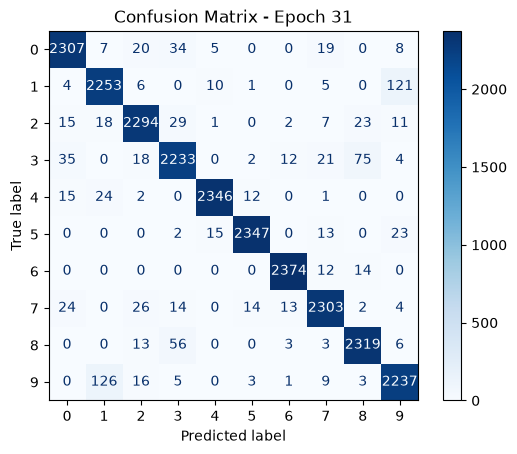

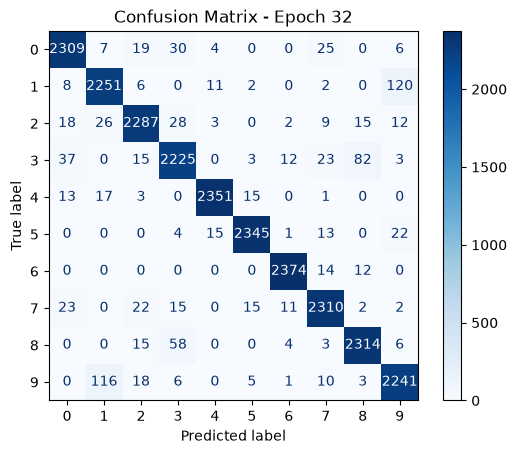

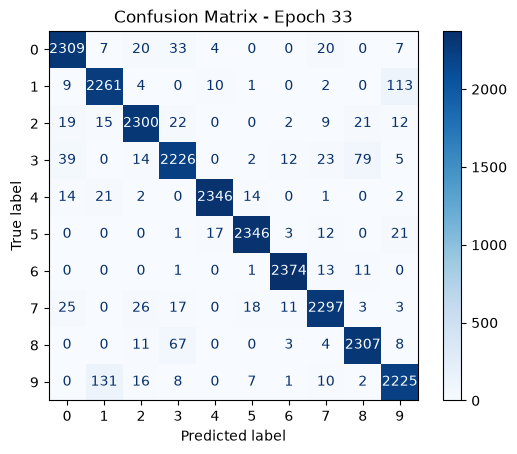

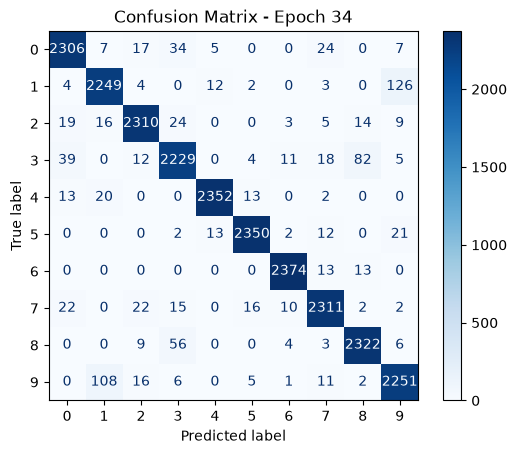

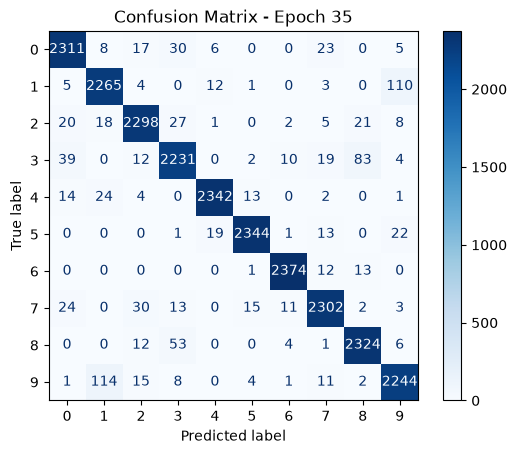

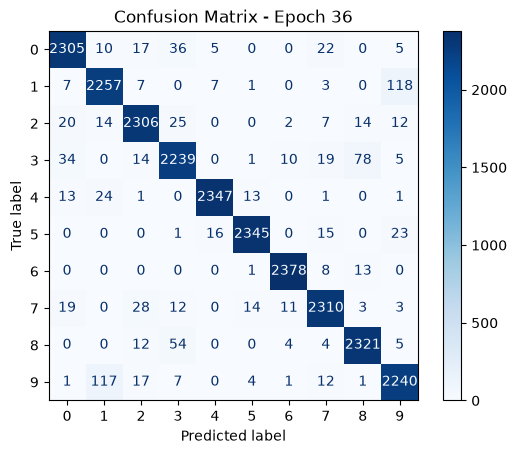

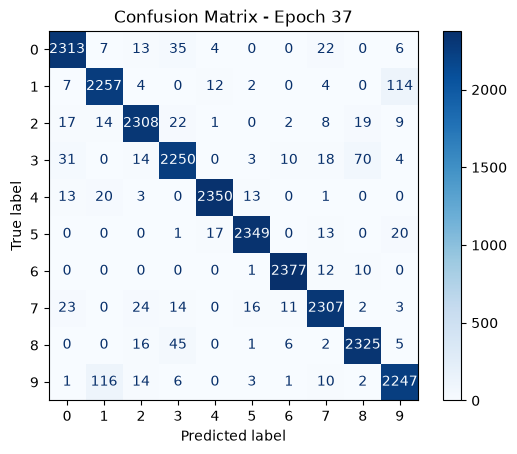

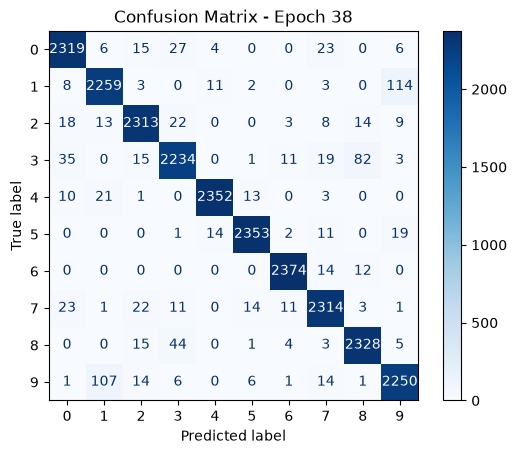

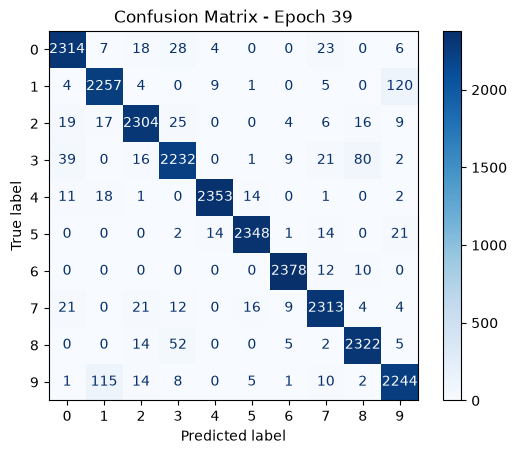

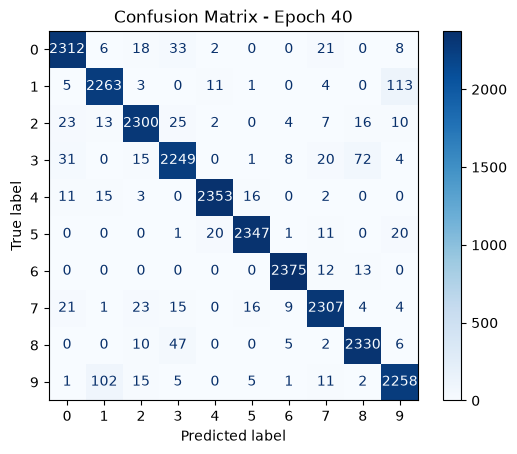

In [28]:
for i, cm in enumerate(all_confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - Epoch {i+1}")
    plt.show()

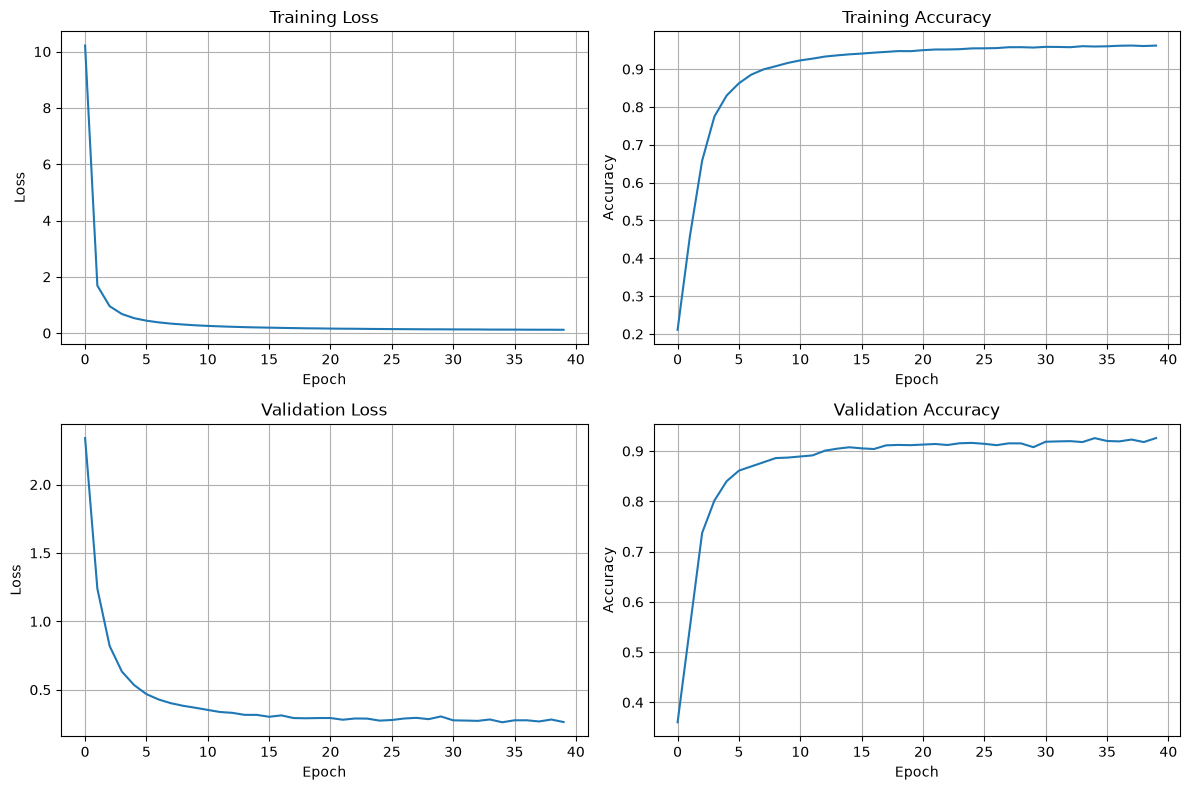

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axs.flatten()

ax1.plot(total_loss_train)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid()

ax2.plot(total_accuracy_train)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.grid()

ax3.plot(total_loss_valid)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.set_title('Validation Loss')
ax3.grid()

ax4.plot(total_accuracy_valid)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Validation Accuracy')  
ax4.grid()

plt.tight_layout()
plt.show()